Evaluating a/e SH maps on TOA grid...
Expanding emissivity map (normalization unnorm)...
Computing step 1/5760
Computing step 2/5760
Computing step 3/5760
Computing step 4/5760
Computing step 5/5760
Computing step 6/5760
Computing step 7/5760
Computing step 8/5760
Computing step 9/5760
Computing step 10/5760
Computing step 11/5760
Computing step 12/5760
Computing step 13/5760
Computing step 14/5760
Computing step 15/5760
Computing step 16/5760
Computing step 17/5760
Computing step 18/5760
Computing step 19/5760
Computing step 20/5760
Computing step 21/5760
Computing step 22/5760
Computing step 23/5760
Computing step 24/5760
Computing step 25/5760
Computing step 26/5760
Computing step 27/5760
Computing step 28/5760
Computing step 29/5760
Computing step 30/5760
Computing step 31/5760
Computing step 32/5760
Computing step 33/5760
Computing step 34/5760
Computing step 35/5760
Computing step 36/5760
Computing step 37/5760
Computing step 38/5760
Computing step 39/5760
Computing step 40/5760


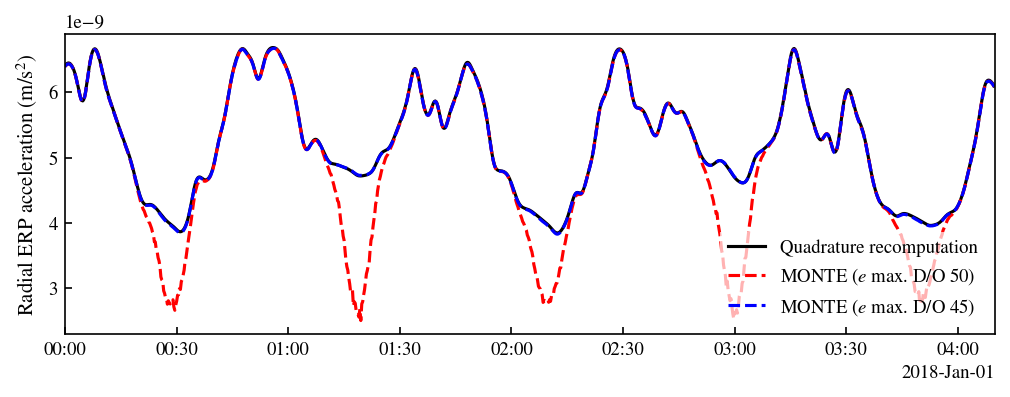

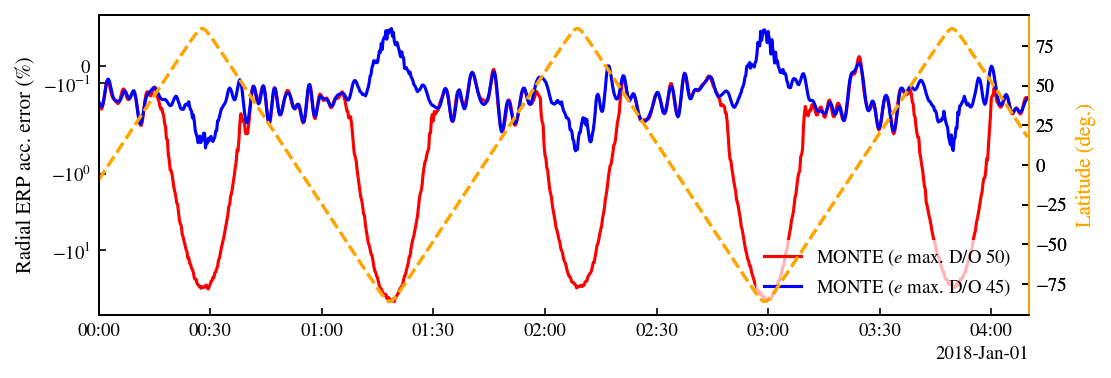

In [2]:
import numpy as np
import sys, os
from SpaceBalls.postproc_EEI_estimation import get_acc_to_flux_factor, get_true_EEI_time_series, estimate_EEI_avg #, get_all_orbital_sma_0, get_stacked_avg_maps_3D_mode
from SpaceBalls.radiation_fluxes_preprocessing import compute_daily_hist_at_sat_r_hist, get_EEI_truth_daily_jd_arrays, get_mid_day_jd_array
from SpaceBalls.utils import normal_smoother, progress_bar, nanrms
import SpaceBalls.input_database_manager as input_manager
from SpaceBalls.sph_meshing import QuadratureGrid, KnockeGridMONTE
from SpaceBalls.plotter import Plotter
import config.constants as constants
import itertools
import random
from SpaceBalls.paths import CONFIG_DIR, MEDIA_DIR, INPUT_DIR, OUTPUT_DIR
import matplotlib.pyplot as plt
from astropy.coordinates import cartesian_to_spherical

grid = QuadratureGrid(0, order=325)

sb_tags_emi = ['SB_R800_35_111', 'SB_R800_35_101']
labels = ['MONTE ($e$ max. D/O 50)', 'MONTE ($e$ max. D/O 45)']
cols = ['r', 'b']

fig, ax = plt.subplots(figsize=(8,2.6))
fig_rel, ax_rel = plt.subplots(figsize=(8,2.6))

for i, sb_tag in enumerate(sb_tags_emi):

    EEI_truth = input_manager.get_dicts(sb_tag)['force_settings']['EEI_truth']
    EEI_truth_name = 'EEI_truth_' + str(EEI_truth)
    day_idx = 0
    max_step_idx = 1000

    r_hist_day = np.load(os.path.join(OUTPUT_DIR, sb_tag, 'day_'+str(day_idx), 'xyz_ecef.npy'))
    _, lat, lon = cartesian_to_spherical(r_hist_day[:,0], r_hist_day[:,1], r_hist_day[:,2])
            
    jd_hist_day = np.load(os.path.join(OUTPUT_DIR, sb_tag, 'day_'+str(day_idx), 'jd_vec.npy'))
    jd_hist_plot = Plotter.jd_to_datetime(jd_hist_day)

    erp_ar_hist = np.load(os.path.join(OUTPUT_DIR, sb_tag, 'day_'+str(day_idx), 'erp.npy'))[:,0] * 1e3

    recomp_erp_Fr_hist, _ = compute_daily_hist_at_sat_r_hist(EEI_truth_name, #'EEI_truth_1', 
                                                            r_hist_day, jd_hist_day, 
                                                            day_idx, toa_grid=grid)
    recomp_erp_ar_hist = recomp_erp_Fr_hist / get_acc_to_flux_factor(sb_tag)

    diff = erp_ar_hist - recomp_erp_ar_hist
    rel_diff = diff / recomp_erp_ar_hist

    if i==0:
        ax.plot(jd_hist_plot[:max_step_idx], recomp_erp_ar_hist[:max_step_idx], color='k', label='Quadrature recomputation')

    ax.plot(jd_hist_plot[:max_step_idx], erp_ar_hist[:max_step_idx], '--', 
            color=cols[i], label=labels[i])

    ax.set_xlim([jd_hist_plot[0], jd_hist_plot[max_step_idx]])
    Plotter.format_time_labels(ax)
    ax.legend(loc='lower right')
    ax.set_ylabel('Radial ERP acceleration (m/s$^2$)')

    ax_rel.plot(jd_hist_plot[:max_step_idx], rel_diff[:max_step_idx]*100, 
                color=cols[i], label=labels[i])
    ax_rel_right = ax_rel.twinx()
    ax_rel_right.plot(jd_hist_plot[:max_step_idx], lat.deg[:max_step_idx], '--', color='orange')
    ax_rel_right.set_ylabel('Latitude (deg.)', color='orange')
    ax_rel_right.spines['right'].set_color('orange')
    ax_rel_right.tick_params(axis='x', colors='orange', which='both')

    ax_rel.set_xlim([jd_hist_plot[0], jd_hist_plot[max_step_idx]])
    Plotter.format_time_labels(ax_rel)
    ax_rel.legend(loc='lower right')
    ax_rel.set_ylabel('Radial ERP acc. error (%)')
    ax_rel.set_yscale('symlog', linthresh=5e-1)



Evaluating a/e SH maps on TOA grid...
Expanding emissivity map (normalization unnorm)...
Computing step 1/5760
Computing step 2/5760
Computing step 3/5760
Computing step 4/5760
Computing step 5/5760
Computing step 6/5760
Computing step 7/5760
Computing step 8/5760
Computing step 9/5760
Computing step 10/5760
Computing step 11/5760
Computing step 12/5760
Computing step 13/5760
Computing step 14/5760
Computing step 15/5760
Computing step 16/5760
Computing step 17/5760
Computing step 18/5760
Computing step 19/5760
Computing step 20/5760
Computing step 21/5760
Computing step 22/5760
Computing step 23/5760
Computing step 24/5760
Computing step 25/5760
Computing step 26/5760
Computing step 27/5760
Computing step 28/5760
Computing step 29/5760
Computing step 30/5760
Computing step 31/5760
Computing step 32/5760
Computing step 33/5760
Computing step 34/5760
Computing step 35/5760
Computing step 36/5760
Computing step 37/5760
Computing step 38/5760
Computing step 39/5760
Computing step 40/5760


/tmp/ipykernel_387211/1447925569.py:55: RuntimeWarning: invalid value encountered in divide
  rel_diff = diff / recomp_erp_ar_hist


Evaluating a/e SH maps on TOA grid...
Expanding albedo map (normalization unnorm)...
Computing step 1/5760
Computing step 2/5760
Computing step 3/5760
Computing step 4/5760
Computing step 5/5760
Computing step 6/5760
Computing step 7/5760
Computing step 8/5760
Computing step 9/5760
Computing step 10/5760
Computing step 11/5760
Computing step 12/5760
Computing step 13/5760
Computing step 14/5760
Computing step 15/5760
Computing step 16/5760
Computing step 17/5760
Computing step 18/5760
Computing step 19/5760
Computing step 20/5760
Computing step 21/5760
Computing step 22/5760
Computing step 23/5760
Computing step 24/5760
Computing step 25/5760
Computing step 26/5760
Computing step 27/5760
Computing step 28/5760
Computing step 29/5760
Computing step 30/5760
Computing step 31/5760
Computing step 32/5760
Computing step 33/5760
Computing step 34/5760
Computing step 35/5760
Computing step 36/5760
Computing step 37/5760
Computing step 38/5760
Computing step 39/5760
Computing step 40/5760
Comp

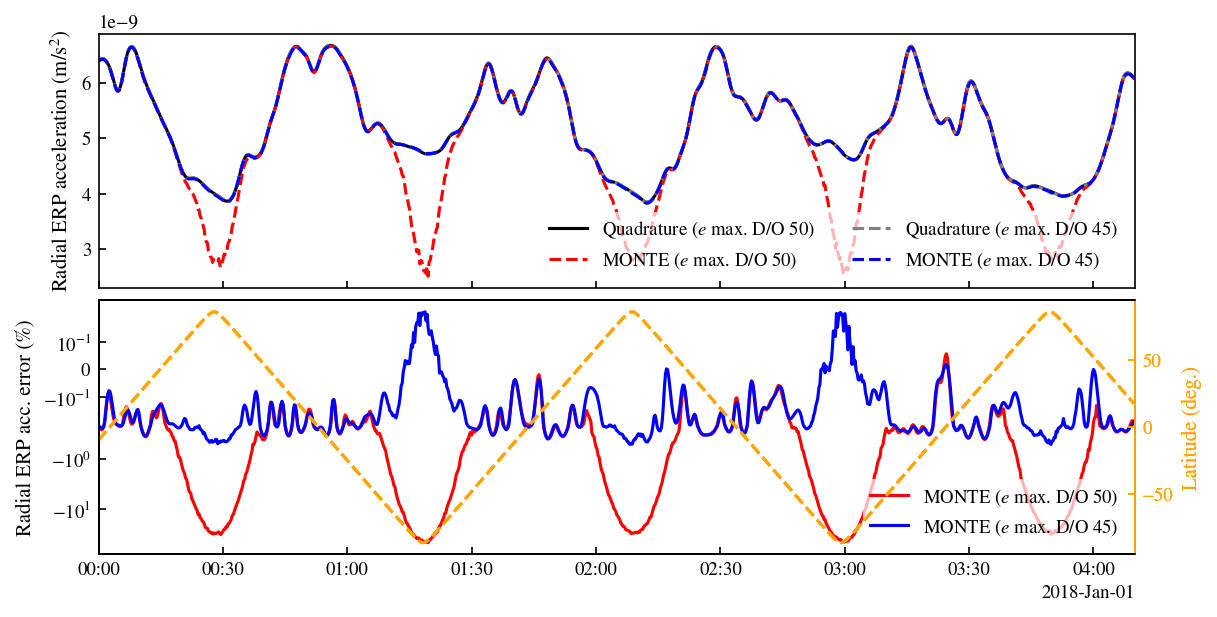

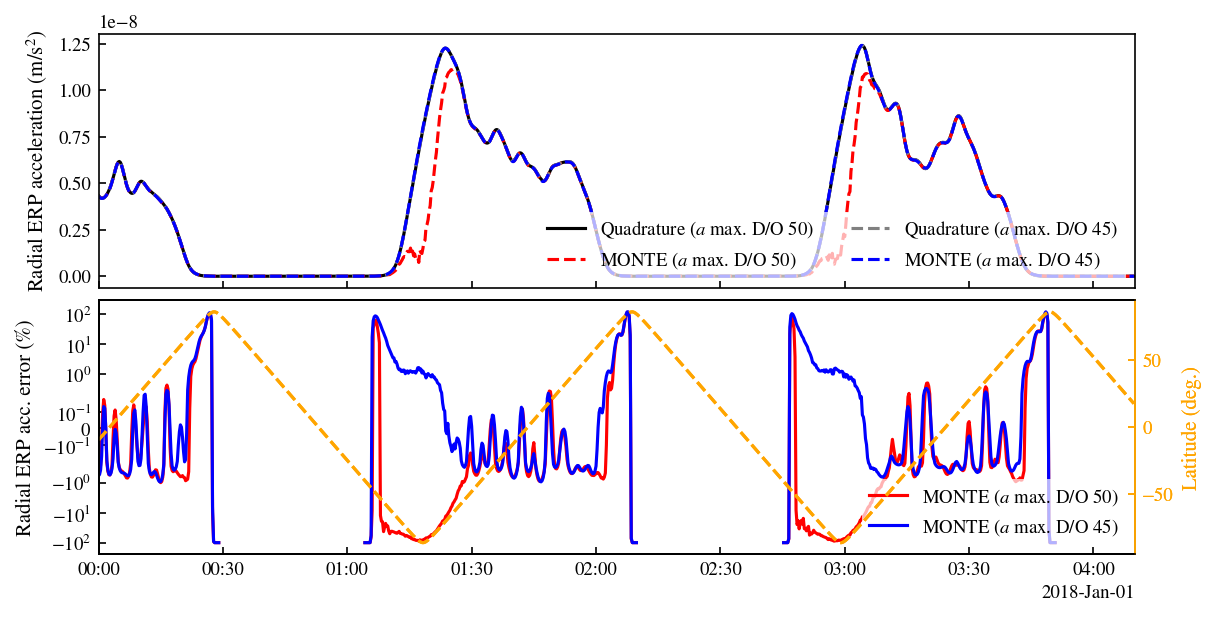

In [13]:
import numpy as np
import sys, os
from SpaceBalls.postproc_EEI_estimation import get_acc_to_flux_factor, get_true_EEI_time_series, estimate_EEI_avg #, get_all_orbital_sma_0, get_stacked_avg_maps_3D_mode
from SpaceBalls.radiation_fluxes_preprocessing import compute_daily_hist_at_sat_r_hist, get_EEI_truth_daily_jd_arrays, get_mid_day_jd_array
from SpaceBalls.utils import normal_smoother, progress_bar, nanrms
import SpaceBalls.input_database_manager as input_manager
from SpaceBalls.sph_meshing import QuadratureGrid, KnockeGridMONTE
from SpaceBalls.plotter import Plotter
import config.constants as constants
import itertools
import random
from SpaceBalls.paths import CONFIG_DIR, MEDIA_DIR, INPUT_DIR, OUTPUT_DIR
import matplotlib.pyplot as plt
from astropy.coordinates import cartesian_to_spherical

grid = QuadratureGrid(0, order=325)

sb_tags_emi = ['SB_R800_35_111', 'SB_R800_35_101']
sb_tags_alb = ['SB_R800_35_110', 'SB_R800_35_100']
all_sb_tags = [sb_tags_emi, sb_tags_alb]

labels_emi = ['($e$ max. D/O 50)', '($e$ max. D/O 45)']
labels_alb = ['($a$ max. D/O 50)', '($a$ max. D/O 45)']
all_labels = [labels_emi, labels_alb]

cols = ['r', 'b']

for j, sb_tags in enumerate(all_sb_tags):
    labels = all_labels[j]

    figs, axs = plt.subplots(2, 1, figsize=(8,4), sharex=True, layout="constrained")
    #fig_rel, ax_rel = plt.subplots(figsize=(8,2.6))

    for i, sb_tag in enumerate(sb_tags):

        EEI_truth = input_manager.get_dicts(sb_tag)['force_settings']['EEI_truth']
        EEI_truth_name = 'EEI_truth_' + str(EEI_truth)
        day_idx = 0
        max_step_idx = 1000

        r_hist_day = np.load(os.path.join(OUTPUT_DIR, sb_tag, 'day_'+str(day_idx), 'xyz_ecef.npy'))
        _, lat, lon = cartesian_to_spherical(r_hist_day[:,0], r_hist_day[:,1], r_hist_day[:,2])
                
        jd_hist_day = np.load(os.path.join(OUTPUT_DIR, sb_tag, 'day_'+str(day_idx), 'jd_vec.npy'))
        jd_hist_plot = Plotter.jd_to_datetime(jd_hist_day)

        erp_ar_hist = np.load(os.path.join(OUTPUT_DIR, sb_tag, 'day_'+str(day_idx), 'erp.npy'))[:,0] * 1e3

        recomp_erp_Fr_hist, _ = compute_daily_hist_at_sat_r_hist(EEI_truth_name, #'EEI_truth_1', 
                                                                r_hist_day, jd_hist_day, 
                                                                day_idx, toa_grid=grid)
        recomp_erp_ar_hist = recomp_erp_Fr_hist / get_acc_to_flux_factor(sb_tag)

        diff = erp_ar_hist - recomp_erp_ar_hist
        rel_diff = diff / recomp_erp_ar_hist

        if i==0:
            axs[0].plot(jd_hist_plot[:max_step_idx], recomp_erp_ar_hist[:max_step_idx], 
                        color='k', label='Quadrature ' + labels[i])
        elif i==1:
            axs[0].plot(jd_hist_plot[:max_step_idx], recomp_erp_ar_hist[:max_step_idx], 
                        '--', color='gray', label='Quadrature ' + labels[i])

        axs[0].plot(jd_hist_plot[:max_step_idx], erp_ar_hist[:max_step_idx], '--', 
                color=cols[i], label='MONTE ' + labels[i])

        axs[0].set_xlim([jd_hist_plot[0], jd_hist_plot[max_step_idx]])
        Plotter.format_time_labels(axs[0])
        axs[0].legend(loc='lower right', ncols=2)
        axs[0].set_ylabel('Radial ERP acceleration (m/s$^2$)')

        axs[1].plot(jd_hist_plot[:max_step_idx], rel_diff[:max_step_idx]*100, 
                    color=cols[i], label='MONTE ' + labels[i])
        ax_rel_right = axs[1].twinx()
        ax_rel_right.plot(jd_hist_plot[:max_step_idx], lat.deg[:max_step_idx], '--', color='orange')
        ax_rel_right.set_ylabel('Latitude (deg.)', color='orange')
        ax_rel_right.spines['right'].set_color('orange')
        ax_rel_right.tick_params(axis='y', colors='orange', which='both')

        axs[1].set_xlim([jd_hist_plot[0], jd_hist_plot[max_step_idx]])
        Plotter.format_time_labels(axs[1])
        axs[1].legend(loc='lower right')
        axs[1].set_ylabel('Radial ERP acc. error (%)')
        axs[1].set_yscale('symlog', linthresh=2e-1)



In [8]:
list(ax_rel_right.spines)

['left', 'right', 'bottom', 'top']